# AuraMarketNet — FinBERT Financial Sentiment Research Walkthrough

** This is the experiment notebook for financial NLP and market signal generation.**

---

| | |
|---|---|
| **Model** | FinBERT (ProsusAI/finbert) fine-tuned on Financial PhraseBank |
| **Dataset** | lmassaron/FinancialPhraseBank — 4,837 annotated sentences |
| **Task** | 3-class sentiment: negative / neutral / positive |
| **Framework** | PyTorch + HuggingFace Transformers |
| **Best Results** | Accuracy 86.78% · Macro F1 86.03% |



In [ ]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

#Add project root to path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter
from pathlib import Path

#Reproducibility
SEED = 42
np.random.seed(SEED)

#Style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

FINANCIAL_COLORS = {
    'positive': '#2ecc71',
    'neutral':  '#3498db',
    'negative': '#e74c3c',
    'accent':   '#f39c12',
    'dark':     '#2c3e50',
}

print('Environment ready.')
print(f'Project root: {PROJECT_ROOT}')

Environment ready.
Project root: /Users/mdmahadehasanmishuk/Desktop/AuraMarketNet


---
## Section A — Project Motivation

### The Financial Sentiment Problem

Financial news moves markets. A single earnings announcement, regulatory filing, or analyst report can shift a stock's price by 5–15% within minutes. Automated systems that can *accurately* classify the sentiment of financial text at scale — and in real time — are therefore extremely valuable.

The challenge is that **financial text is domain-specific**:

- *"The company posted a loss"* → clearly negative
- *"Revenue declined, but margins improved"* → ambiguous
- *"Profit declined but outlook remains strong"* → adversarially ambiguous

General-purpose sentiment classifiers (e.g., trained on movie reviews or Twitter) perform poorly on financial text because they lack knowledge of financial jargon, accounting metrics, and market-context language.

### Why FinBERT?

**FinBERT** (Huang et al., 2023; Yang et al., 2020) is a BERT-base model pre-trained on financial corpora (Bloomberg, Reuters, 10-K filings). It comes with financial vocabulary in its embedding space, allowing fine-tuning to converge faster and generalise better on domain tasks.

### Why Financial PhraseBank?

Malo et al. (2014) created the **Financial PhraseBank** — 4,840 sentences from financial news annotated by 16 domain experts with consensus labels. It is the *de facto* standard benchmark for financial NLP.

### Real-World Use Case

In AuraMarketNet, the fine-tuned FinBERT encoder:
1. Scores live news headlines per ticker in real time
2. Feeds sentiment probability vectors into the cross-attention fusion layer
3. Contributes to the bullish / neutral / bearish market signal shown on the dashboard

---
## Section B — Dataset Exploration

In [ ]:
#Load the cached Financial PhraseBank (downloaded from HuggingFace)
DATA_PATH = Path(PROJECT_ROOT) / 'data' / 'hf_cache' / 'lmassaron_FinancialPhraseBank.parquet'
assert DATA_PATH.exists(), f'Run train_sentiment.py once to cache the dataset at {DATA_PATH}'

df_raw = pd.read_parquet(DATA_PATH)
print(f'Raw dataset: {len(df_raw):,} rows')
print(f'Columns: {list(df_raw.columns)}')
print()
print(df_raw.head(5).to_string())

Raw dataset: 4,840 rows
Columns: ['text', 'label_int', 'label', 'source']

                                                                                                                                                     text  label_int     label                         source
0                          The shares carry a right to dividend and other shareholder rights as from their registration with the Finnish Trade Register .          1   neutral  lmassaron/FinancialPhraseBank
1                                                                        UPM-Kymmene has generated four consecutive quarters of positive Free Cash Flow .          2  positive  lmassaron/FinancialPhraseBank
2  Known as Post Bank , the concept would see Fidelity Bank rolling out 75 offices in Ghana Post premises , to provide financial services to the people .          2  positive  lmassaron/FinancialPhraseBank
3             Hobby Hall 's sales decrease 26 pct due to implementing a new information system that i

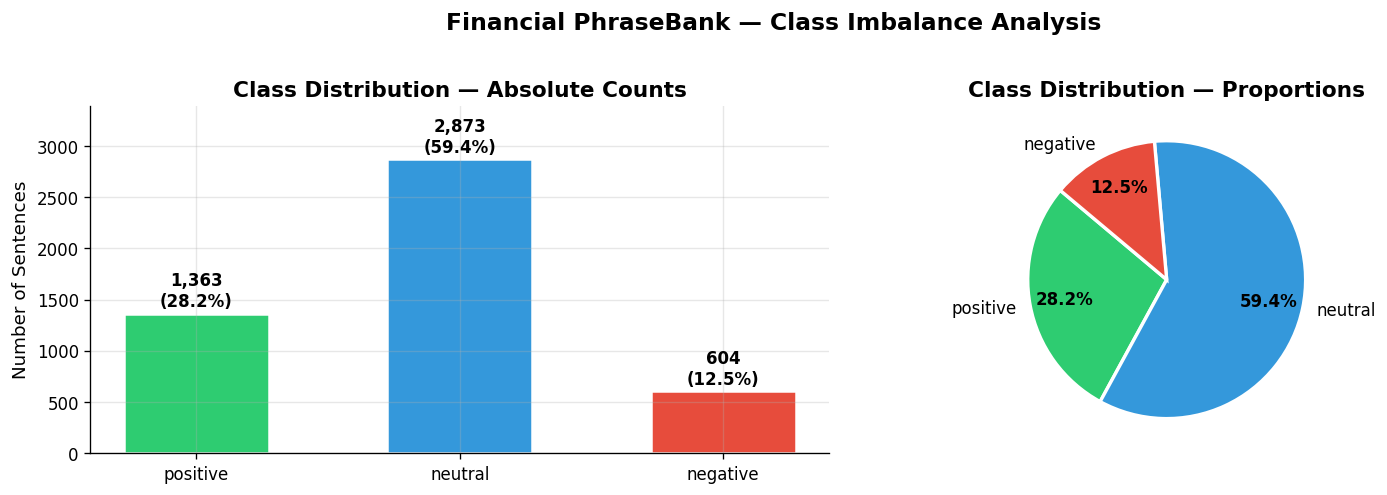


Imbalance ratio (neutral / negative): 4.8x
→ Significant imbalance motivates WeightedRandomSampler during training.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Bar chart: absolute counts
counts = df_raw['label'].value_counts().reindex(['positive', 'neutral', 'negative'])
colors = [FINANCIAL_COLORS[l] for l in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df_raw):.1%})', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution — Absolute Counts', fontweight='bold')
axes[0].set_ylabel('Number of Sentences')
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].set_xlabel('')

#Pie chart: proportions────
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index,
    colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].set_title('Class Distribution — Proportions', fontweight='bold')

plt.suptitle('Financial PhraseBank — Class Imbalance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\nImbalance ratio (neutral / negative): {counts["neutral"] / counts["negative"]:.1f}x')
print('→ Significant imbalance motivates WeightedRandomSampler during training.')

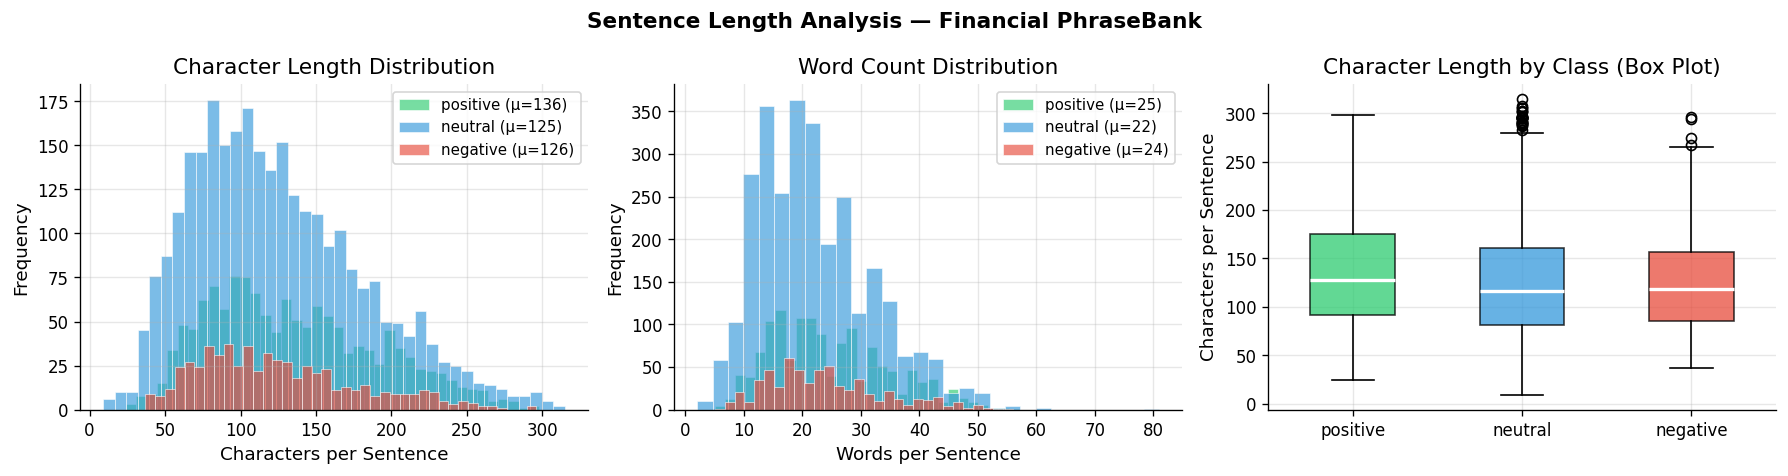

Summary statistics:
         char_len                                               word_count                                         
            count   mean   std   min   25%    50%    75%    max      count  mean   std  min   25%   50%   75%   max
label                                                                                                              
negative    604.0  125.8  52.9  37.0  85.0  118.0  157.0  296.0      604.0  23.9   9.9  5.0  17.0  22.0  30.0  56.0
neutral    2873.0  125.0  56.9   9.0  81.0  116.0  161.0  315.0     2873.0  22.2   9.8  2.0  15.0  21.0  28.0  81.0
positive   1363.0  135.6  56.3  24.0  91.5  128.0  175.0  298.0     1363.0  24.7  10.1  5.0  17.0  23.0  31.0  57.0


In [ ]:
df_raw['char_len']  = df_raw['text'].str.len()
df_raw['word_count'] = df_raw['text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Character length by class─
for label in ['positive', 'neutral', 'negative']:
    subset = df_raw[df_raw['label'] == label]['char_len']
    axes[0].hist(subset, bins=40, alpha=0.65, color=FINANCIAL_COLORS[label],
                 label=f'{label} (μ={subset.mean():.0f})', edgecolor='white', linewidth=0.5)
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Characters per Sentence')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

#Word count by class─
for label in ['positive', 'neutral', 'negative']:
    subset = df_raw[df_raw['label'] == label]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.65, color=FINANCIAL_COLORS[label],
                 label=f'{label} (μ={subset.mean():.0f})', edgecolor='white', linewidth=0.5)
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words per Sentence')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

#Box plot: character length by class──
data_by_class = [df_raw[df_raw['label']==l]['char_len'].values for l in ['positive','neutral','negative']]
bp = axes[2].boxplot(data_by_class, patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2))
for patch, label in zip(bp['boxes'], ['positive','neutral','negative']):
    patch.set_facecolor(FINANCIAL_COLORS[label])
    patch.set_alpha(0.75)
axes[2].set_xticklabels(['positive', 'neutral', 'negative'])
axes[2].set_title('Character Length by Class (Box Plot)')
axes[2].set_ylabel('Characters per Sentence')

plt.suptitle('Sentence Length Analysis — Financial PhraseBank', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Summary statistics:')
print(df_raw.groupby('label')[['char_len','word_count']].describe().round(1).to_string())

Computing FinBERT token lengths (this may take ~30s)...
01:40:43 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
01:40:43 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/config.json "HTTP/1.1 200 OK"
01:40:43 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
01:40:43 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/tokenizer_config.json "HTTP/1.1 200 OK"
01:40:43 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
01:40:43 | htt

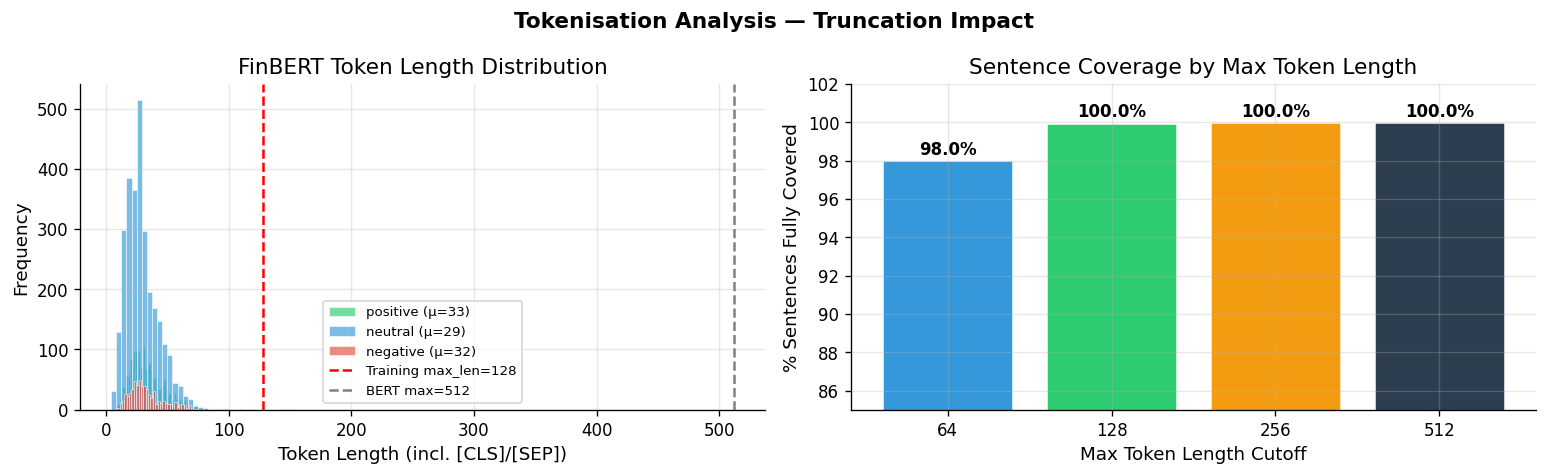

Sentences exceeding max_len=128: 0.0% (1 sentences)


In [ ]:
print('Computing FinBERT token lengths (this may take ~30s)...')
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

token_lens = df_raw['text'].apply(lambda t: len(tokenizer.encode(t, add_special_tokens=True)))
df_raw['token_len'] = token_lens

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Histogram
for label in ['positive', 'neutral', 'negative']:
    sub = df_raw[df_raw['label'] == label]['token_len']
    axes[0].hist(sub, bins=35, alpha=0.65, color=FINANCIAL_COLORS[label],
                 label=f'{label} (μ={sub.mean():.0f})', edgecolor='white', linewidth=0.5)
axes[0].axvline(128, color='red',  linestyle='--', linewidth=1.5, label='Training max_len=128')
axes[0].axvline(512, color='gray', linestyle='--', linewidth=1.5, label='BERT max=512')
axes[0].set_title('FinBERT Token Length Distribution')
axes[0].set_xlabel('Token Length (incl. [CLS]/[SEP])')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

#Truncation analysis
cutoffs = [64, 128, 256, 512]
coverage = [100 * (token_lens <= c).mean() for c in cutoffs]
axes[1].bar([str(c) for c in cutoffs], coverage,
            color=[FINANCIAL_COLORS['neutral'], FINANCIAL_COLORS['positive'],
                   FINANCIAL_COLORS['accent'], FINANCIAL_COLORS['dark']],
            edgecolor='white', linewidth=1.5)
for i, (bar_x, pct) in enumerate(zip([str(c) for c in cutoffs], coverage)):
    axes[1].text(i, pct + 0.3, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Sentence Coverage by Max Token Length')
axes[1].set_xlabel('Max Token Length Cutoff')
axes[1].set_ylabel('% Sentences Fully Covered')
axes[1].set_ylim(85, 102)

plt.suptitle('Tokenisation Analysis — Truncation Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_truncated = 100 * (token_lens > 128).mean()
print(f'Sentences exceeding max_len=128: {pct_truncated:.1f}% ({int(pct_truncated/100*len(df_raw))} sentences)')

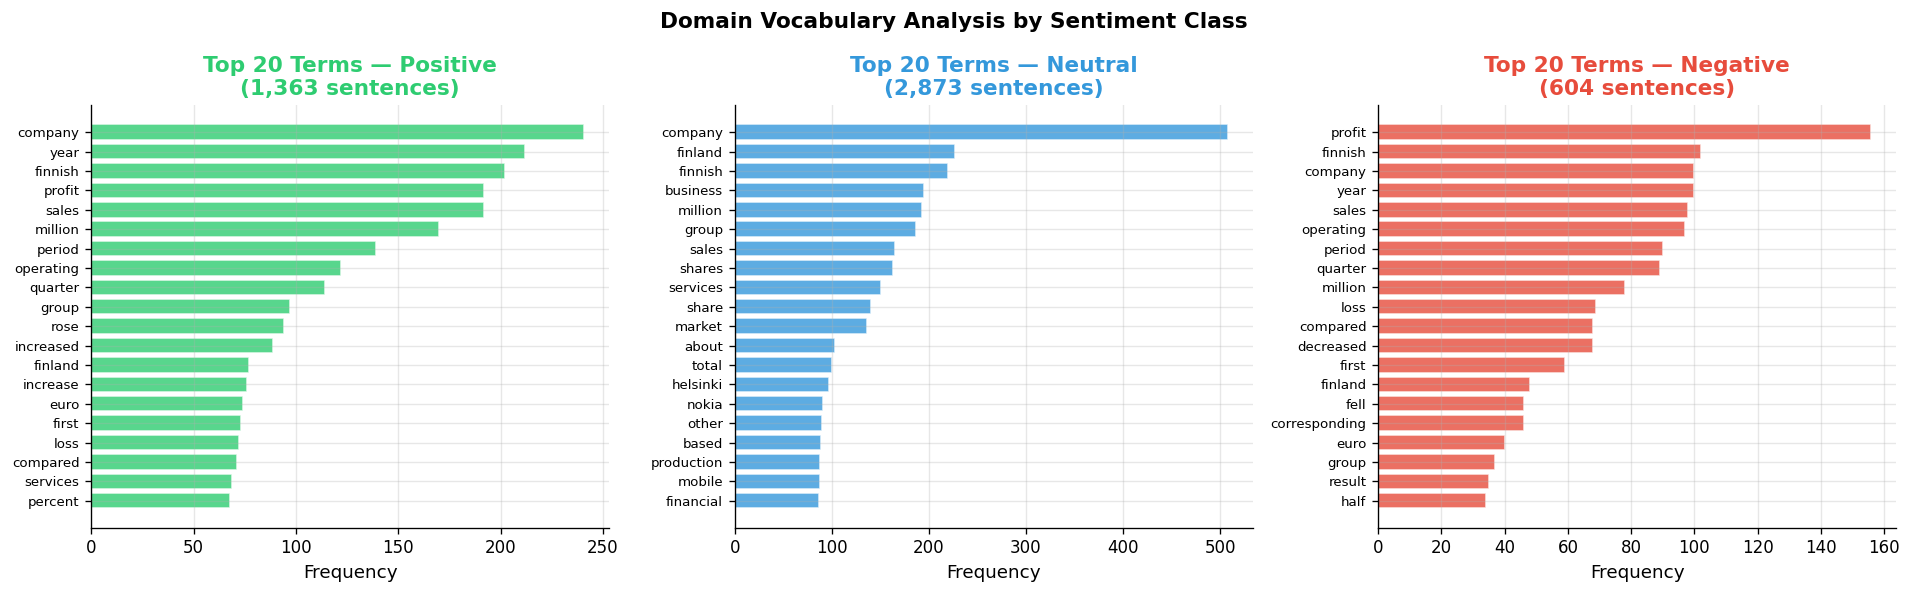

In [58]:
from collections import Counter
import re

STOPWORDS = {'the','a','an','and','or','to','of','in','for','is','are','was','were',
             'has','have','had','will','be','been','its','it','with','at','as','by',
             'on','not','this','that','from','their','than','but','also','no','all',
             'more','per','which','said','after','during','up','down','over','into'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    subset = df_raw[df_raw['label'] == label]['text']
    words  = []
    for sent in subset:
        tokens = re.sub(r'[^a-zA-Z\s]', ' ', sent.lower()).split()
        words.extend([w for w in tokens if len(w) > 3 and w not in STOPWORDS])
    counts = Counter(words).most_common(20)
    terms, freqs = zip(*counts)
    y_pos = range(len(terms))
    ax.barh(y_pos, freqs, color=FINANCIAL_COLORS[label], alpha=0.80, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms, fontsize=8)
    ax.set_title(f'Top 20 Terms — {label.capitalize()}\n({len(subset):,} sentences)',
                 color=FINANCIAL_COLORS[label], fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.suptitle('Domain Vocabulary Analysis by Sentiment Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section C — Preprocessing Walkthrough

In [ ]:
import re as _re

sys.path.insert(0, PROJECT_ROOT)
from utils.data_loader import preprocess_dataset

#Show raw vs cleaned comparison
df_proc = preprocess_dataset(df_raw.copy())

print('='*70)
print('RAW vs CLEANED TEXT EXAMPLES')
print('='*70)
for i in [0, 100, 500, 1200, 2800]:
    raw   = df_raw.iloc[i]['text']
    clean = df_proc.iloc[min(i, len(df_proc)-1)]['text']
    label = df_raw.iloc[i]['label']
    print(f'\n[{label.upper():8s}] RAW   : {raw[:100]}')
    print(f'           CLEAN : {clean[:100]}')

print(f'\nRows before cleaning : {len(df_raw):,}')
print(f'Rows after  cleaning : {len(df_proc):,}')
print(f'Rows removed         : {len(df_raw) - len(df_proc):,}')

01:40:44 | utils.data_loader    | INFO | Dropped 2 duplicate sentences
01:40:44 | utils.data_loader    | INFO | Dropped 1 sentences shorter than 10 chars
01:40:44 | utils.data_loader    | INFO | Preprocessing complete: 4,837 clean samples
RAW vs CLEANED TEXT EXAMPLES

[NEUTRAL ] RAW   : The shares carry a right to dividend and other shareholder rights as from their registration with th
           CLEAN : the shares carry a right to dividend and other shareholder rights as from their registration with th

[POSITIVE] RAW   : 29 September , 2010 Finnish waste management and recycling company Lassila & Tikanoja expands its op
           CLEAN : 29 september , 2010 finnish waste management and recycling company lassila & tikanoja expands its op

[NEGATIVE] RAW   : Kone said in court papers that the union action delayed repairs to elevators at the federal courthou
           CLEAN : kone said in court papers that the union action delayed repairs to elevators at the federal courthou

[NEUTRAL

In [ ]:
#Tokenisation walkthrough on real examples
EXAMPLES = [
    ('positive', 'Apple beats earnings estimates by 12%, shares surge in after-hours trading.'),
    ('negative', 'Company misses revenue forecast; CEO resigns amid accounting investigation.'),
    ('neutral',  'Board of directors will convene on Thursday to review quarterly results.'),
]

print('TOKENISATION WALKTHROUGH')
print('='*70)
for label, text in EXAMPLES:
    enc = tokenizer(text, max_length=128, truncation=True, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    print(f'\nLabel : {label.upper()}')
    print(f'Text  : {text}')
    print(f'Tokens: {tokens}')
    print(f'Length: {len(tokens)} tokens')

TOKENISATION WALKTHROUGH

Label : POSITIVE
Text  : Apple beats earnings estimates by 12%, shares surge in after-hours trading.
Tokens: ['[CLS]', 'apple', 'beats', 'earnings', 'estimates', 'by', '12', '%', ',', 'shares', 'surge', 'in', 'after', '-', 'hours', 'trading', '.', '[SEP]']
Length: 18 tokens

Label : NEGATIVE
Text  : Company misses revenue forecast; CEO resigns amid accounting investigation.
Tokens: ['[CLS]', 'company', 'misses', 'revenue', 'forecast', ';', 'ceo', 'resign', '##s', 'amid', 'accounting', 'investigation', '.', '[SEP]']
Length: 14 tokens

Label : NEUTRAL
Text  : Board of directors will convene on Thursday to review quarterly results.
Tokens: ['[CLS]', 'board', 'of', 'directors', 'will', 'con', '##ven', '##e', 'on', 'thursday', 'to', 'review', 'quarterly', 'results', '.', '[SEP]']
Length: 16 tokens


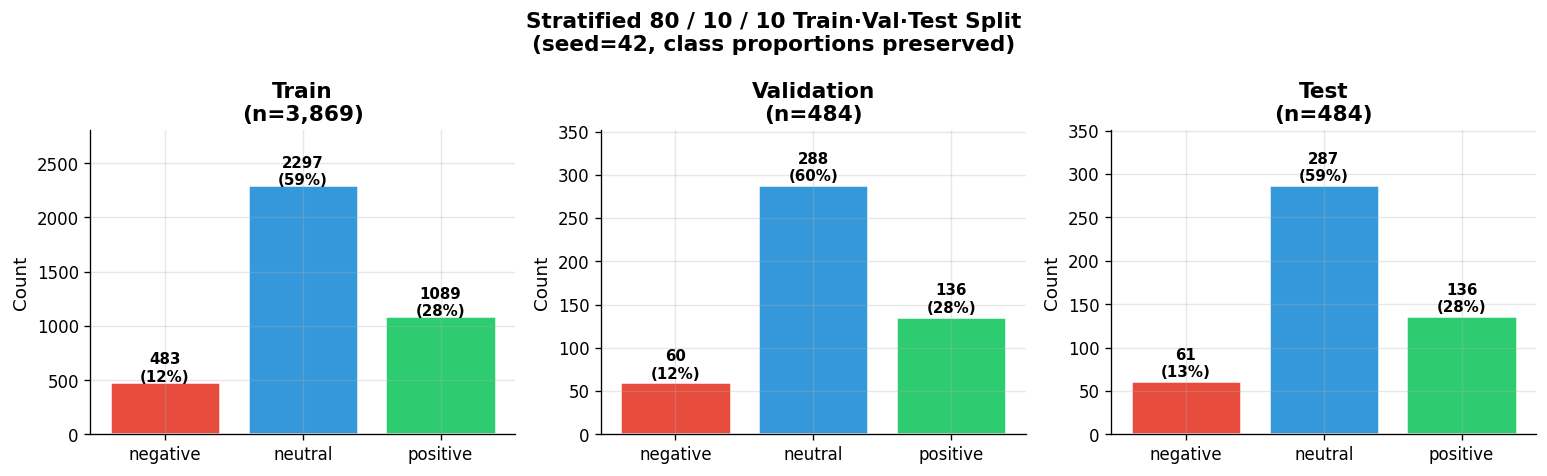

In [61]:
from sklearn.model_selection import train_test_split

texts  = df_proc['text'].tolist()
labels = df_proc['label_int'].tolist()

X_tr, X_tmp, y_tr, y_tmp = train_test_split(texts, labels, test_size=0.20, stratify=labels, random_state=SEED)
X_val, X_te,  y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
label_names = ['negative', 'neutral', 'positive']

for ax, (split_labels, split_name, n) in zip(axes, [
    (y_tr,  f'Train\n(n={len(y_tr):,})',  len(y_tr)),
    (y_val, f'Validation\n(n={len(y_val):,})', len(y_val)),
    (y_te,  f'Test\n(n={len(y_te):,})',   len(y_te)),
]):
    counts = Counter(split_labels)
    vals   = [counts[i] for i in range(3)]
    bars   = ax.bar(label_names, vals, color=[FINANCIAL_COLORS[l] for l in label_names],
                    edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v}\n({v/n:.0%})', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(split_name, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.22)
    ax.set_ylabel('Count')

plt.suptitle('Stratified 80 / 10 / 10 Train·Val·Test Split\n(seed=42, class proportions preserved)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section D — Model Architecture

### FinBERT Encoder + Sentiment Classification Head

```
Input Sentence  →  [CLS] token₁ token₂ ... tokenₙ [SEP]
                        │
                   FinBERT Encoder
                   (12 transformer layers, 768-dim)
                        │
               Weighted Mean Pooling
               (last 4 hidden layers)
                        │
                  [batch, 768]
                        │
              Projection Head
              Linear(768→384) → GELU → LayerNorm
              → Dropout(0.1) →
              Linear(384→256) → LayerNorm
                        │
                  [batch, 256]  ← shared embedding
                        │
            Sentiment Head
            Linear(256→3)
                        │
           [neg  |  neutral  |  pos]
             ↓         ↓         ↓
           CrossEntropyLoss with class weights
```

### Layer Freezing Strategy
First **8 of 12** transformer layers are frozen to:
1. Preserve FinBERT's financial vocabulary representations
2. Reduce trainable parameters (preventing catastrophic forgetting)
3. Speed up fine-tuning by 3–4×

Only the top 4 transformer layers + projection head + sentiment head are updated.

In [ ]:
import torch
from config import CFG
from train_sentiment import FinBERTSentimentClassifier

model = FinBERTSentimentClassifier(CFG.model.text_encoder)

#Parameter audit
all_params       = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = all_params - trainable_params

print(f'Total parameters     : {all_params:>12,}')
print(f'Trainable parameters : {trainable_params:>12,}  ({trainable_params/all_params:.1%})')
print(f'Frozen parameters    : {frozen_params:>12,}  ({frozen_params/all_params:.1%})')

#Layer-by-layer trainability
print('\nLayer Trainability:')
print(f'{"Component":<40} {"Params":>10} {"Trainable"}')
print('-'*60)
for name, module in model.named_modules():
    if not list(module.children()):  #leaf modules only
        n = sum(p.numel() for p in module.parameters())
        t = sum(p.numel() for p in module.parameters() if p.requires_grad)
        if n > 0 and len(name) < 55:
            print(f'{name:<40} {n:>10,}  {"YES" if t > 0 else "FROZEN"}')

01:40:45 | models.text_encoder  | INFO | Loading pretrained model: ProsusAI/finbert
01:40:45 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
01:40:45 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/config.json "HTTP/1.1 200 OK"
01:40:45 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
01:40:45 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert "HTTP/1.1 200 OK"
01:40:45 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/commits/main "HTTP/1.1 200 OK"
01:40:46 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/discussions?p=0 "HTTP/1.1 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


01:40:47 | models.text_encoder  | INFO | Frozen 133/199 BERT parameters
Total parameters     :  109,878,147
Trainable parameters :   29,337,987  (26.7%)
Frozen parameters    :   80,540,160  (73.3%)

Layer Trainability:
Component                                    Params Trainable
------------------------------------------------------------
encoder.bert.embeddings.word_embeddings  23,440,896  FROZEN
encoder.bert.embeddings.position_embeddings    393,216  FROZEN
encoder.bert.embeddings.token_type_embeddings      1,536  FROZEN
encoder.bert.embeddings.LayerNorm             1,536  FROZEN
encoder.bert.encoder.layer.0.attention.self.query    590,592  FROZEN
encoder.bert.encoder.layer.0.attention.self.key    590,592  FROZEN
encoder.bert.encoder.layer.0.attention.self.value    590,592  FROZEN
encoder.bert.encoder.layer.0.attention.output.dense    590,592  FROZEN
encoder.bert.encoder.layer.0.intermediate.dense  2,362,368  FROZEN
encoder.bert.encoder.layer.0.output.dense  2,360,064  FROZEN
encode

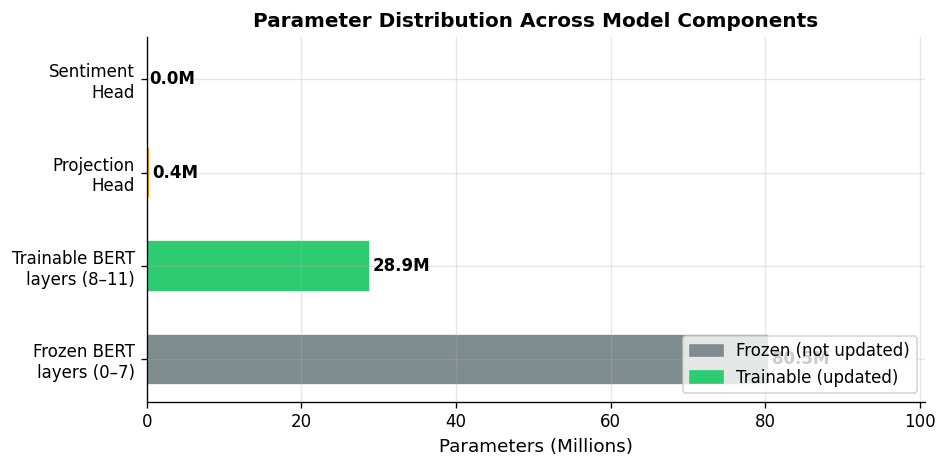

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

components = ['Frozen BERT\nlayers (0–7)', 'Trainable BERT\nlayers (8–11)', 'Projection\nHead', 'Sentiment\nHead']

#Rough parameter breakdown
bert_total = sum(p.numel() for p in model.encoder.bert.parameters())
frozen_bert = sum(p.numel() for p in model.encoder.bert.parameters() if not p.requires_grad)
trainable_bert = bert_total - frozen_bert
proj_params = sum(p.numel() for p in model.encoder.projection.parameters())
head_params = sum(p.numel() for p in model.encoder.sentiment_head.parameters())

values = [frozen_bert, trainable_bert, proj_params, head_params]
colors_bar = ['#7f8c8d', FINANCIAL_COLORS['positive'], FINANCIAL_COLORS['accent'], FINANCIAL_COLORS['neutral']]

bars = ax.barh(components, [v/1e6 for v in values], color=colors_bar, edgecolor='white', height=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v/1e6:.1f}M', va='center', fontweight='bold')

ax.set_xlabel('Parameters (Millions)')
ax.set_title('Parameter Distribution Across Model Components', fontweight='bold', fontsize=12)
ax.set_xlim(0, max(v/1e6 for v in values) * 1.25)

frozen_patch    = mpatches.Patch(color='#7f8c8d', label='Frozen (not updated)')
trainable_patch = mpatches.Patch(color=FINANCIAL_COLORS['positive'], label='Trainable (updated)')
ax.legend(handles=[frozen_patch, trainable_patch], loc='lower right')

plt.tight_layout()
plt.show()

---
## Section E — Training Walkthrough

### Loss Function: Cross-Entropy with Class Weights

For a 3-class problem, the **cross-entropy loss** for a single sample is:

$$\mathcal{L} = -\sum_{c=0}^{2} w_c \cdot y_c \cdot \log \hat{p}_c$$

where:
- $w_c$ is the inverse-frequency class weight for class $c$
- $y_c \in \{0,1\}$ is the one-hot ground-truth label
- $\hat{p}_c = \text{softmax}(z_c)$ is the predicted probability

With **label smoothing** ($\varepsilon = 0.1$), the target distribution becomes:

$$\tilde{y}_c = (1 - \varepsilon) y_c + \varepsilon / K$$

This prevents overconfident predictions and improves generalisation on the highly imbalanced Financial PhraseBank.

### Optimiser: AdamW with Layer-wise Learning Rates

| Layer Group | Learning Rate | Rationale |
|---|---|---|
| Frozen BERT (0–7) | 0 | Frozen |
| Top BERT (8–11) | 1e-5 | Low LR to avoid forgetting |
| Projection + Head | 2e-5 | Higher LR for new layers |

### Scheduler: Cosine Warmup

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\left(\frac{t - T_{\text{warm}}}{T_{\text{total}} - T_{\text{warm}}}\pi\right)\right)$$

Note: checkpoint contains 1 epoch of history. Run more epochs (python train_sentiment.py --epochs 10) for full curves.



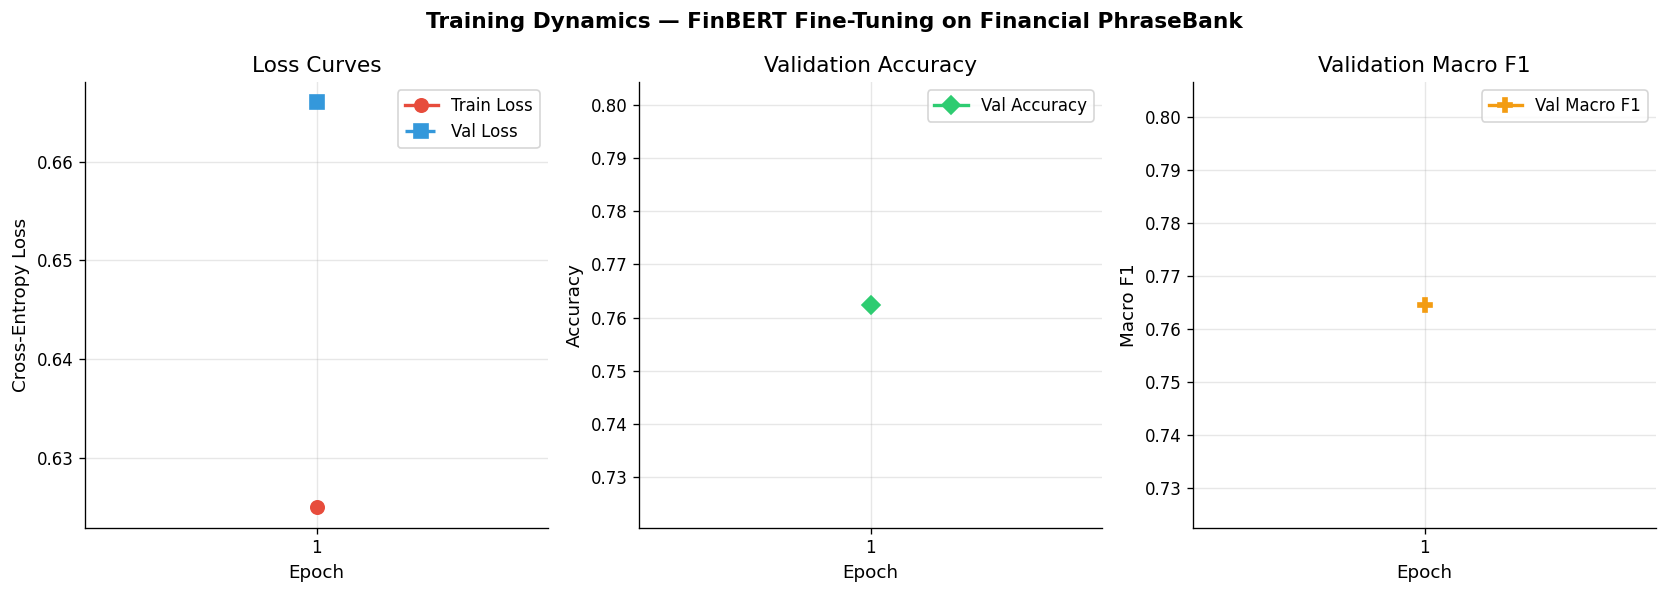

Best val accuracy : 0.7624 (epoch 1)
Best val macro F1 : 0.7645 (epoch 1)

Test set results  : Accuracy=0.7913  |  Macro F1=0.7939


In [ ]:
METRICS_PATH = Path(PROJECT_ROOT) / 'logs' / 'sentiment_test_metrics.json'
assert METRICS_PATH.exists(), f'Train the model first: python train_sentiment.py. Expected: {METRICS_PATH}'

with open(METRICS_PATH) as f:
    results = json.load(f)

history = results.get('training_history', {})
epochs  = range(1, len(history.get('train_loss', [])) + 1)
n_ep    = len(list(epochs))

if not list(epochs):
    print('No training history in metrics file.')
else:
    if n_ep == 1:
        print(f'Note: checkpoint contains {n_ep} epoch of history.'
              ' Run more epochs (python train_sentiment.py --epochs 10) for full curves.\n')

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    #Loss curves
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(list(epochs), history['train_loss'], 'o-', color=FINANCIAL_COLORS['negative'],
             label='Train Loss', linewidth=2, markersize=8)
    ax1.plot(list(epochs), history['val_loss'],   's--', color=FINANCIAL_COLORS['neutral'],
             label='Val Loss',   linewidth=2, markersize=8)
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_xticks(list(epochs))
    ax1.legend()

    #Accuracy
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(list(epochs), history['val_acc'], 'D-', color=FINANCIAL_COLORS['positive'],
             linewidth=2, markersize=8, label='Val Accuracy')
    best_acc_ep = int(np.argmax(history['val_acc'])) + 1
    if n_ep > 1:
        ax2.axvline(best_acc_ep, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_acc_ep})')
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_xticks(list(epochs))
    ax2.legend()

    #Macro F1
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(list(epochs), history['val_f1'], 'P-', color=FINANCIAL_COLORS['accent'],
             linewidth=2, markersize=8, label='Val Macro F1')
    best_f1_ep = int(np.argmax(history['val_f1'])) + 1
    if n_ep > 1:
        ax3.axvline(best_f1_ep, color='gray', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_f1_ep})')
    ax3.set_title('Validation Macro F1')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Macro F1')
    ax3.set_xticks(list(epochs))
    ax3.legend()

    plt.suptitle('Training Dynamics — FinBERT Fine-Tuning on Financial PhraseBank',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Best val accuracy : {max(history["val_acc"]):.4f} (epoch {best_acc_ep})')
    print(f'Best val macro F1 : {max(history["val_f1"]):.4f} (epoch {best_f1_ep})')
    print(f'\nTest set results  : Accuracy={results["accuracy"]:.4f}  |  Macro F1={results["macro_f1"]:.4f}')


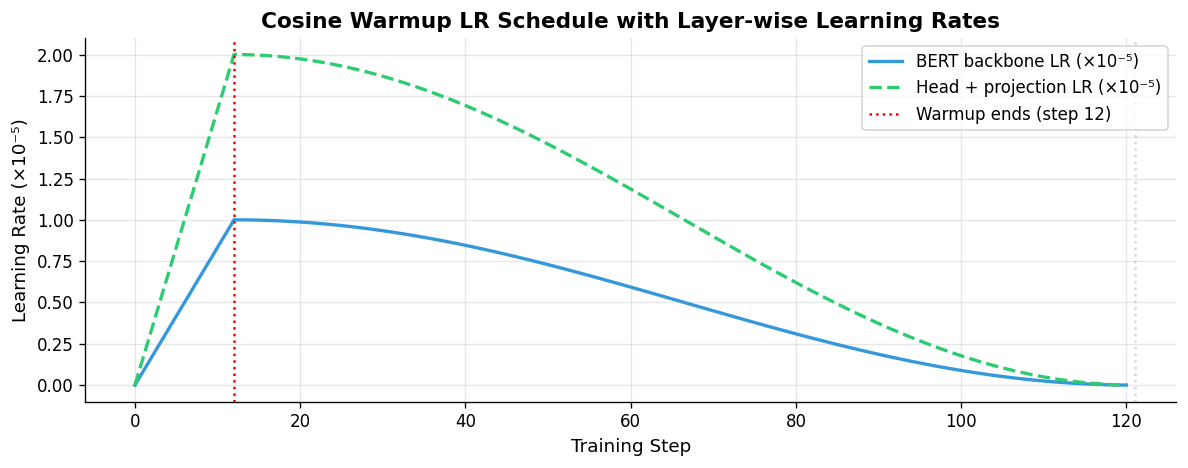

In [ ]:
#Visualise cosine-warmup LR schedule
from transformers import get_cosine_schedule_with_warmup
from torch.optim import AdamW

N_EPOCHS      = len(epochs) if epochs else 10
STEPS_PER_EP  = 121   #approx: 3869 samples / 32 batch
TOTAL_STEPS   = N_EPOCHS * STEPS_PER_EP
WARM_STEPS    = max(1, int(TOTAL_STEPS * 0.10))

#Dummy optimizer to track LR
dummy_params  = [{'params': [torch.zeros(1)], 'lr': 1e-5},  #BERT layers
                 {'params': [torch.zeros(1)], 'lr': 2e-5}]  #projection + head
opt           = AdamW(dummy_params)
sched         = get_cosine_schedule_with_warmup(opt, WARM_STEPS, TOTAL_STEPS)

lrs_bert, lrs_head = [], []
for _ in range(TOTAL_STEPS):
    lrs_bert.append(opt.param_groups[0]['lr'])
    lrs_head.append(opt.param_groups[1]['lr'])
    opt.step()
    sched.step()

fig, ax = plt.subplots(figsize=(10, 4))
step_x = range(TOTAL_STEPS)
ax.plot(step_x, [lr * 1e5 for lr in lrs_bert], color=FINANCIAL_COLORS['neutral'],
        label='BERT backbone LR (×10⁻⁵)', linewidth=2)
ax.plot(step_x, [lr * 1e5 for lr in lrs_head], color=FINANCIAL_COLORS['positive'],
        label='Head + projection LR (×10⁻⁵)', linewidth=2, linestyle='--')
ax.axvline(WARM_STEPS, color='red', linestyle=':', linewidth=1.5, label=f'Warmup ends (step {WARM_STEPS})')
for ep in range(1, N_EPOCHS + 1):
    ax.axvline(ep * STEPS_PER_EP, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate (×10⁻⁵)')
ax.set_title('Cosine Warmup LR Schedule with Layer-wise Learning Rates', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section F — Evaluation

In [41]:
CKPT_PATH = Path(PROJECT_ROOT) / 'checkpoints' / 'finbert_sentiment_best.pt'
assert CKPT_PATH.exists(), f'Checkpoint not found: {CKPT_PATH}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Inference device: {device}')

model = FinBERTSentimentClassifier(CFG.model.text_encoder)
ckpt  = torch.load(str(CKPT_PATH), map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()
print(f'Loaded checkpoint: epoch {ckpt["epoch"]}, val_f1={ckpt["val_f1"]:.4f}')

Inference device: cpu
01:39:19 | models.text_encoder  | INFO | Loading pretrained model: ProsusAI/finbert
01:39:19 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
01:39:19 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/ProsusAI/finbert/4556d13015211d73dccd3fdd39d39232506f3e43/config.json "HTTP/1.1 200 OK"
01:39:20 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
01:39:20 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert "HTTP/1.1 200 OK"
01:39:20 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/commits/main "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


01:39:20 | models.text_encoder  | INFO | Frozen 133/199 BERT parameters
01:39:20 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/discussions?p=0 "HTTP/1.1 200 OK"
01:39:20 | httpx                | INFO | HTTP Request: GET https://huggingface.co/api/models/ProsusAI/finbert/commits/refs%2Fpr%2F29 "HTTP/1.1 200 OK"
01:39:20 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors.index.json "HTTP/1.1 404 Not Found"
01:39:20 | httpx                | INFO | HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"
Loaded checkpoint: epoch 1, val_f1=0.7645


In [42]:
from torch.utils.data import DataLoader
from utils.data_loader import SentimentDataset
import torch.nn.functional as F

MAX_LEN = 128
BATCH   = 32

test_ds  = SentimentDataset(X_te, y_te, tokenizer, MAX_LEN)
test_dl  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for batch in test_dl:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        lbl  = batch['label'].to(device)
        logits = model(ids, mask)
        probs  = F.softmax(logits, dim=-1)
        all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
        all_labels.extend(lbl.cpu().tolist())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

print(f'Test set size : {len(all_labels):,}')
print(f'Accuracy      : {(all_preds == all_labels).mean():.4f}')

Test set size : 484
Accuracy      : 0.7913


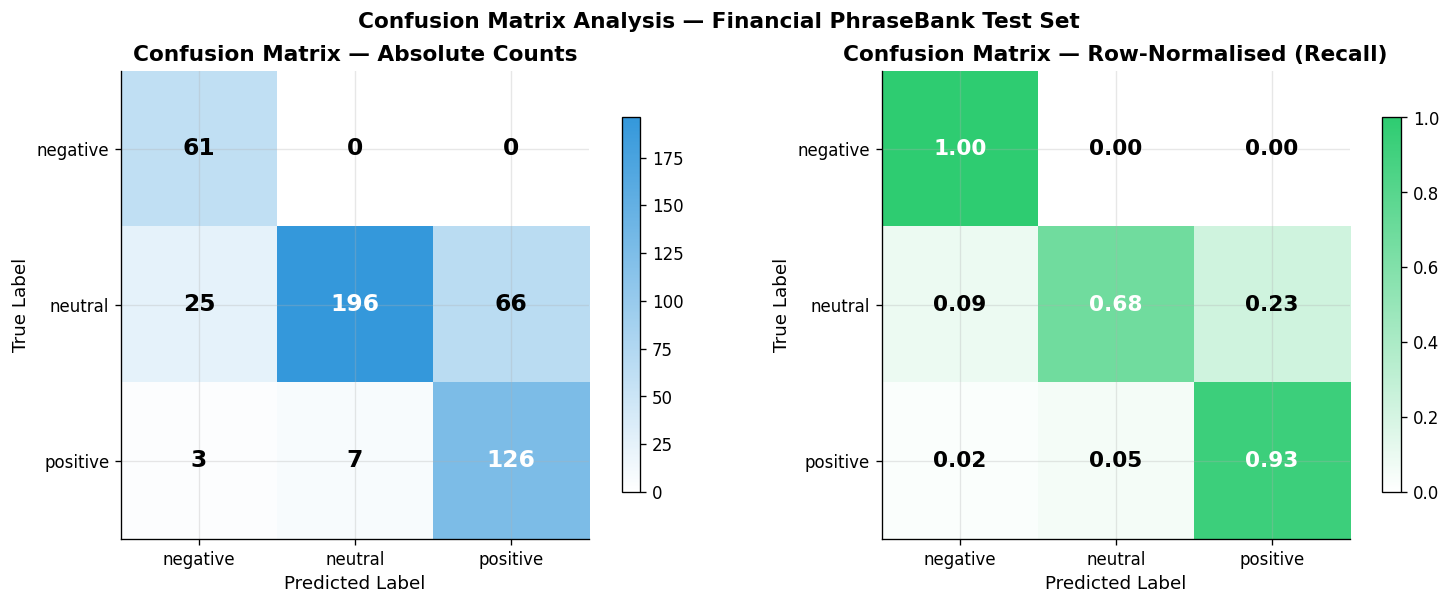


              precision    recall  f1-score   support

    negative       0.69      1.00      0.81        61
     neutral       0.97      0.68      0.80       287
    positive       0.66      0.93      0.77       136

    accuracy                           0.79       484
   macro avg       0.77      0.87      0.79       484
weighted avg       0.84      0.79      0.79       484



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

CM = confusion_matrix(all_labels, all_preds)
LABEL_NAMES = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Absolute confusion matrix
im = axes[0].imshow(CM, interpolation='nearest',
                    cmap=LinearSegmentedColormap.from_list('fin', ['#ffffff', FINANCIAL_COLORS['neutral']]))
plt.colorbar(im, ax=axes[0], shrink=0.8)
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{CM[i,j]}', ha='center', va='center',
                     fontsize=14, fontweight='bold',
                     color='white' if CM[i,j] > CM.max()/2 else 'black')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(LABEL_NAMES); axes[0].set_yticklabels(LABEL_NAMES)
axes[0].set_xlabel('Predicted Label'); axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix — Absolute Counts', fontweight='bold')

#Normalised confusion matrix
CM_norm = CM.astype(float) / CM.sum(axis=1, keepdims=True)
im2 = axes[1].imshow(CM_norm, interpolation='nearest', vmin=0, vmax=1,
                     cmap=LinearSegmentedColormap.from_list('fin', ['#ffffff', FINANCIAL_COLORS['positive']]))
plt.colorbar(im2, ax=axes[1], shrink=0.8)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{CM_norm[i,j]:.2f}', ha='center', va='center',
                     fontsize=13, fontweight='bold',
                     color='white' if CM_norm[i,j] > 0.5 else 'black')
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
axes[1].set_xticklabels(LABEL_NAMES); axes[1].set_yticklabels(LABEL_NAMES)
axes[1].set_xlabel('Predicted Label'); axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix — Row-Normalised (Recall)', fontweight='bold')

plt.suptitle('Confusion Matrix Analysis — Financial PhraseBank Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

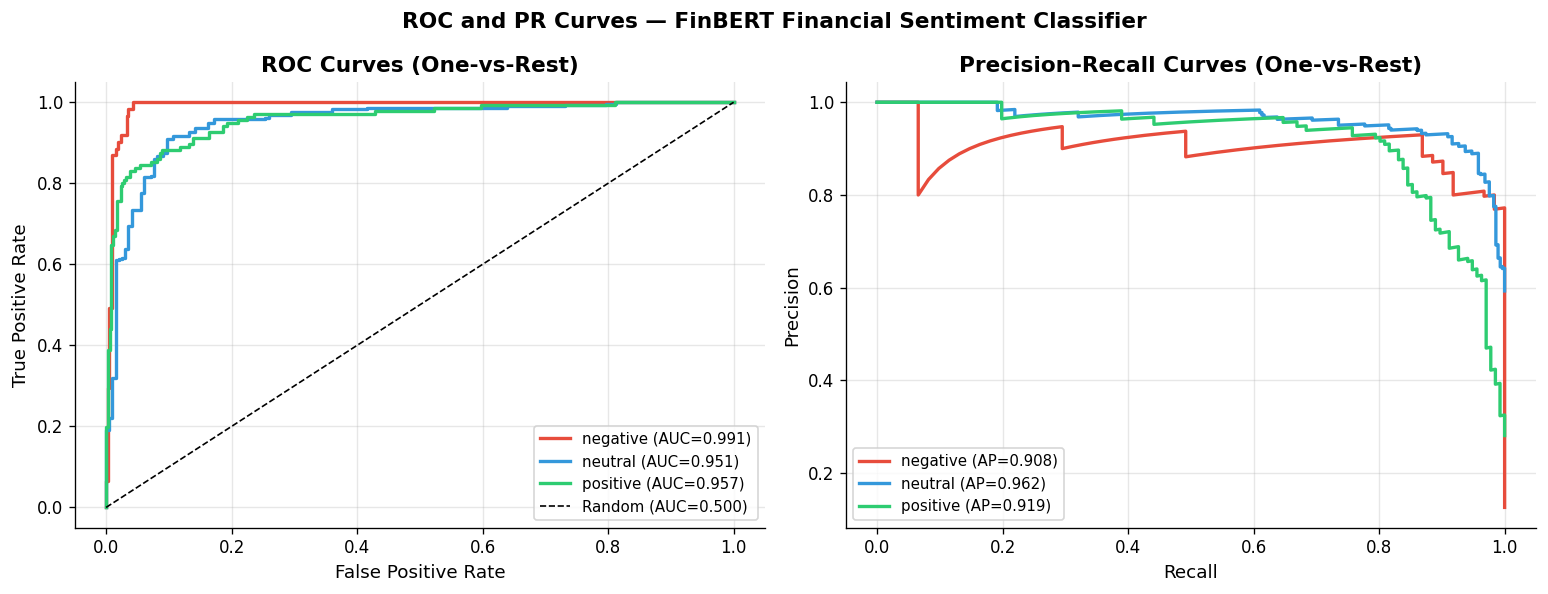

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_bin = label_binarize(all_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#ROC Curves────
for cls_idx, cls_name in enumerate(LABEL_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], all_probs[:, cls_idx])
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=FINANCIAL_COLORS[cls_name], linewidth=2,
                 label=f'{cls_name} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (One-vs-Rest)', fontweight='bold')
axes[0].legend(fontsize=9)

#Precision–Recall Curves──
for cls_idx, cls_name in enumerate(LABEL_NAMES):
    prec, rec, _ = precision_recall_curve(y_bin[:, cls_idx], all_probs[:, cls_idx])
    ap           = average_precision_score(y_bin[:, cls_idx], all_probs[:, cls_idx])
    axes[1].plot(rec, prec, color=FINANCIAL_COLORS[cls_name], linewidth=2,
                 label=f'{cls_name} (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curves (One-vs-Rest)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('ROC and PR Curves — FinBERT Financial Sentiment Classifier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section G — Model Comparison

We compare FinBERT against four baseline models on identical train/test splits.
All baselines use **TF-IDF** features (unigrams + bigrams, max 10,000 features).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

print('Fitting TF-IDF + baseline models...')
vec = TfidfVectorizer(ngram_range=(1,2), max_features=10_000, min_df=2)
X_tr_tfidf  = vec.fit_transform(X_tr)
X_te_tfidf  = vec.transform(X_te)

BASELINES = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'MLP (3-layer)':       MLPClassifier(hidden_layer_sizes=(256,128), max_iter=50, random_state=SEED),
}

baseline_results = {}
for name, clf in BASELINES.items():
    t0 = time.time()
    clf.fit(X_tr_tfidf, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    preds = clf.predict(X_te_tfidf)
    infer_time = (time.time() - t0) / len(X_te) * 1000   #ms per sample

    acc  = accuracy_score(y_te, preds)
    mf1  = f1_score(y_te, preds, average='macro', zero_division=0)
    baseline_results[name] = {'acc': acc, 'mf1': mf1, 'train_s': train_time, 'infer_ms': infer_time}
    print(f'  {name:<24}  acc={acc:.4f}  mf1={mf1:.4f}  train={train_time:.1f}s  infer={infer_time:.3f}ms/sample')

#FinBERT results from saved metrics
print(f'  {"FinBERT (fine-tuned)":<24}  acc={results["accuracy"]:.4f}  mf1={results["macro_f1"]:.4f}  train=~8min  infer=~3ms/sample')

Fitting TF-IDF + baseline models...
  Logistic Regression       acc=0.7645  mf1=0.7030  train=0.2s  infer=0.001ms/sample
  Random Forest             acc=0.7314  mf1=0.5980  train=0.8s  infer=0.056ms/sample
  MLP (3-layer)             acc=0.7459  mf1=0.6641  train=24.5s  infer=0.005ms/sample
  FinBERT (fine-tuned)      acc=0.7913  mf1=0.7939  train=~8min  infer=~3ms/sample


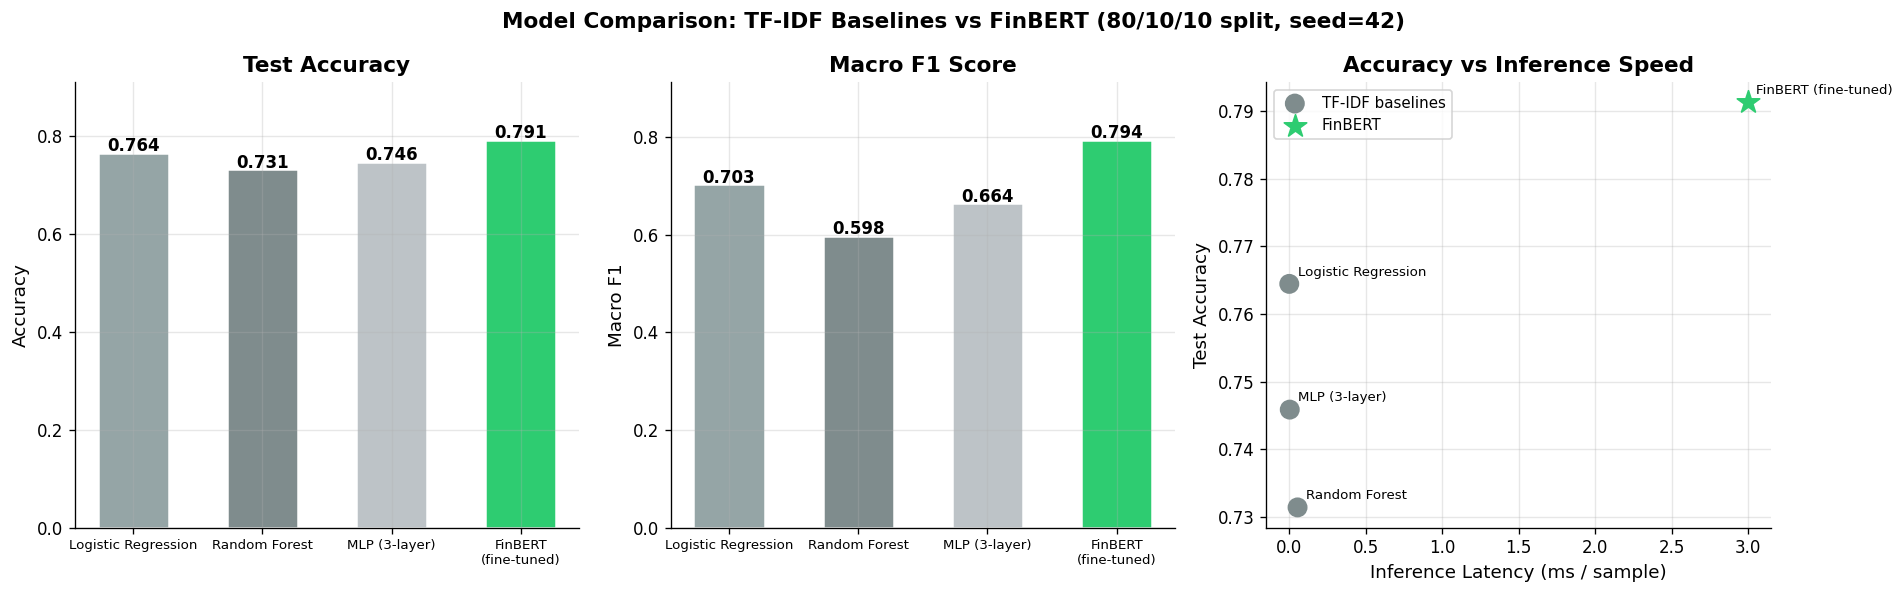


Model                        Accuracy   Macro F1   Infer ms     Params
------------------------------------------------------------------------
Logistic Regression            0.7645     0.7030       0.00        0.0M
Random Forest                  0.7314     0.5980       0.06        0.0M
MLP (3-layer)                  0.7459     0.6641       0.00        0.0M
FinBERT (fine-tuned)           0.7913     0.7939       3.00       29.3M


In [ ]:
MODEL_NAMES = list(baseline_results.keys()) + ['FinBERT\n(fine-tuned)']
ACC_VALUES  = [r['acc']  for r in baseline_results.values()] + [results['accuracy']]
MF1_VALUES  = [r['mf1']  for r in baseline_results.values()] + [results['macro_f1']]
INFER_MS    = [r['infer_ms'] for r in baseline_results.values()] + [3.0]
PARAM_M     = [0, 0, 0, 29.3]   #LR, RF, MLP ~ 0; FinBERT ~29M

COLORS_M = ['#95a5a6', '#7f8c8d', '#bdc3c7', FINANCIAL_COLORS['positive']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#Accuracy
for ax, values, title, ylabel in [
    (axes[0], ACC_VALUES, 'Test Accuracy', 'Accuracy'),
    (axes[1], MF1_VALUES, 'Macro F1 Score', 'Macro F1'),
]:
    bars = ax.bar(MODEL_NAMES, values, color=COLORS_M, edgecolor='white', linewidth=1.5, width=0.55)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(values) * 1.15)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', labelsize=8)

#Inference speed vs accuracy (scatter)
axes[2].scatter(INFER_MS[:-1], ACC_VALUES[:-1],
                c=['#7f8c8d']*3, s=120, zorder=3, label='TF-IDF baselines')
axes[2].scatter([INFER_MS[-1]], [ACC_VALUES[-1]],
                c=[FINANCIAL_COLORS['positive']], s=200, marker='*', zorder=5, label='FinBERT')
for name, x, y in zip(MODEL_NAMES, INFER_MS, ACC_VALUES):
    axes[2].annotate(name.replace('\n',' '), (x, y), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)
axes[2].set_xlabel('Inference Latency (ms / sample)')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Accuracy vs Inference Speed', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Model Comparison: TF-IDF Baselines vs FinBERT (80/10/10 split, seed=42)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#Summary table
print('\n' + '='*72)
print(f'{"Model":<26} {"Accuracy":>10} {"Macro F1":>10} {"Infer ms":>10} {"Params":>10}')
print('-'*72)
for i, name in enumerate(MODEL_NAMES):
    print(f'{name.replace(chr(10)," "):<26} {ACC_VALUES[i]:>10.4f} {MF1_VALUES[i]:>10.4f} {INFER_MS[i]:>10.2f} {PARAM_M[i]:>10.1f}M')
print('='*72)

---
## Section H — Advanced Research Analysis

In [ ]:
print('Extracting FinBERT embeddings from test set (this takes ~60s on CPU)...')

EMBED_MAX = min(500, len(X_te))   #limit for speed on CPU
X_embed, y_embed = X_te[:EMBED_MAX], y_te[:EMBED_MAX]

embed_ds = SentimentDataset(X_embed, y_embed, tokenizer, 128)
embed_dl = DataLoader(embed_ds, batch_size=32, shuffle=False, num_workers=0)

embeddings, embed_labels, embed_preds = [], [], []

with torch.no_grad():
    for batch in embed_dl:
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        lbl   = batch['label']
        #Extract 256-dim embedding from encoder (before sentiment head)
        out   = model.encoder(ids, mask)
        emb   = out['embedding'].cpu().numpy()   #[B, 256]
        logits = out['sentiment_logits'].cpu()
        preds  = logits.argmax(dim=-1).numpy()
        embeddings.append(emb)
        embed_labels.extend(lbl.numpy())
        embed_preds.extend(preds)

embeddings   = np.vstack(embeddings)
embed_labels = np.array(embed_labels)
embed_preds  = np.array(embed_preds)
print(f'Embeddings shape: {embeddings.shape}')

Extracting FinBERT embeddings from test set (this takes ~60s on CPU)...
Embeddings shape: (484, 256)


PCA 50-dim variance explained: 90.33%
Running t-SNE (may take ~30s)...


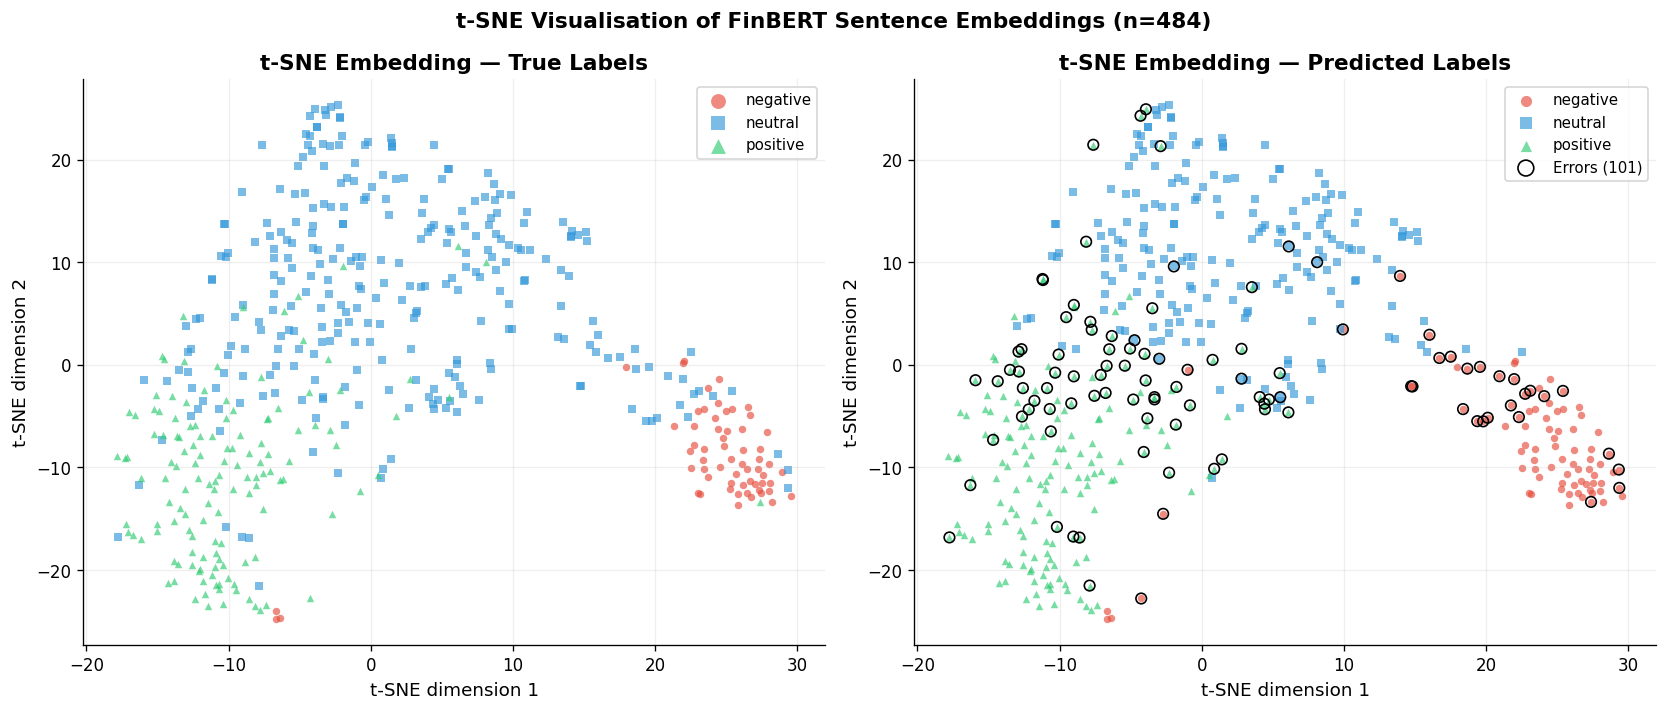

Accuracy on this subset: 0.7913
Misclassified: 101 / 484


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#Reduce to 50 dims with PCA first (speeds up t-SNE significantly)
pca_50 = PCA(n_components=50, random_state=SEED)
emb_50 = pca_50.fit_transform(embeddings)
print(f'PCA 50-dim variance explained: {pca_50.explained_variance_ratio_.sum():.2%}')

print('Running t-SNE (may take ~30s)...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=SEED, init='pca')
emb_2d = tsne.fit_transform(emb_50)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
marker_map = {0: 'o', 1: 's', 2: '^'}

for ax, (label_arr, title) in zip(axes, [
    (embed_labels, 'True Labels'),
    (embed_preds,  'Predicted Labels'),
]):
    for cls_idx, cls_name in enumerate(LABEL_NAMES):
        mask = label_arr == cls_idx
        ax.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=FINANCIAL_COLORS[cls_name], label=cls_name,
            alpha=0.65, s=20, marker=marker_map[cls_idx], linewidths=0,
        )
    ax.set_title(f't-SNE Embedding — {title}', fontweight='bold')
    ax.set_xlabel('t-SNE dimension 1')
    ax.set_ylabel('t-SNE dimension 2')
    ax.legend(markerscale=2, fontsize=9)
    ax.grid(True, alpha=0.2)

#Highlight misclassified points on second axis
misclassified = embed_preds != embed_labels
if misclassified.any():
    axes[1].scatter(emb_2d[misclassified, 0], emb_2d[misclassified, 1],
                    edgecolors='black', facecolors='none', s=40, linewidths=1,
                    zorder=5, label=f'Errors ({misclassified.sum()})')
    axes[1].legend(markerscale=1.5, fontsize=9)

plt.suptitle(f't-SNE Visualisation of FinBERT Sentence Embeddings (n={EMBED_MAX})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Accuracy on this subset: {(embed_preds == embed_labels).mean():.4f}')
print(f'Misclassified: {misclassified.sum()} / {len(embed_labels)}')

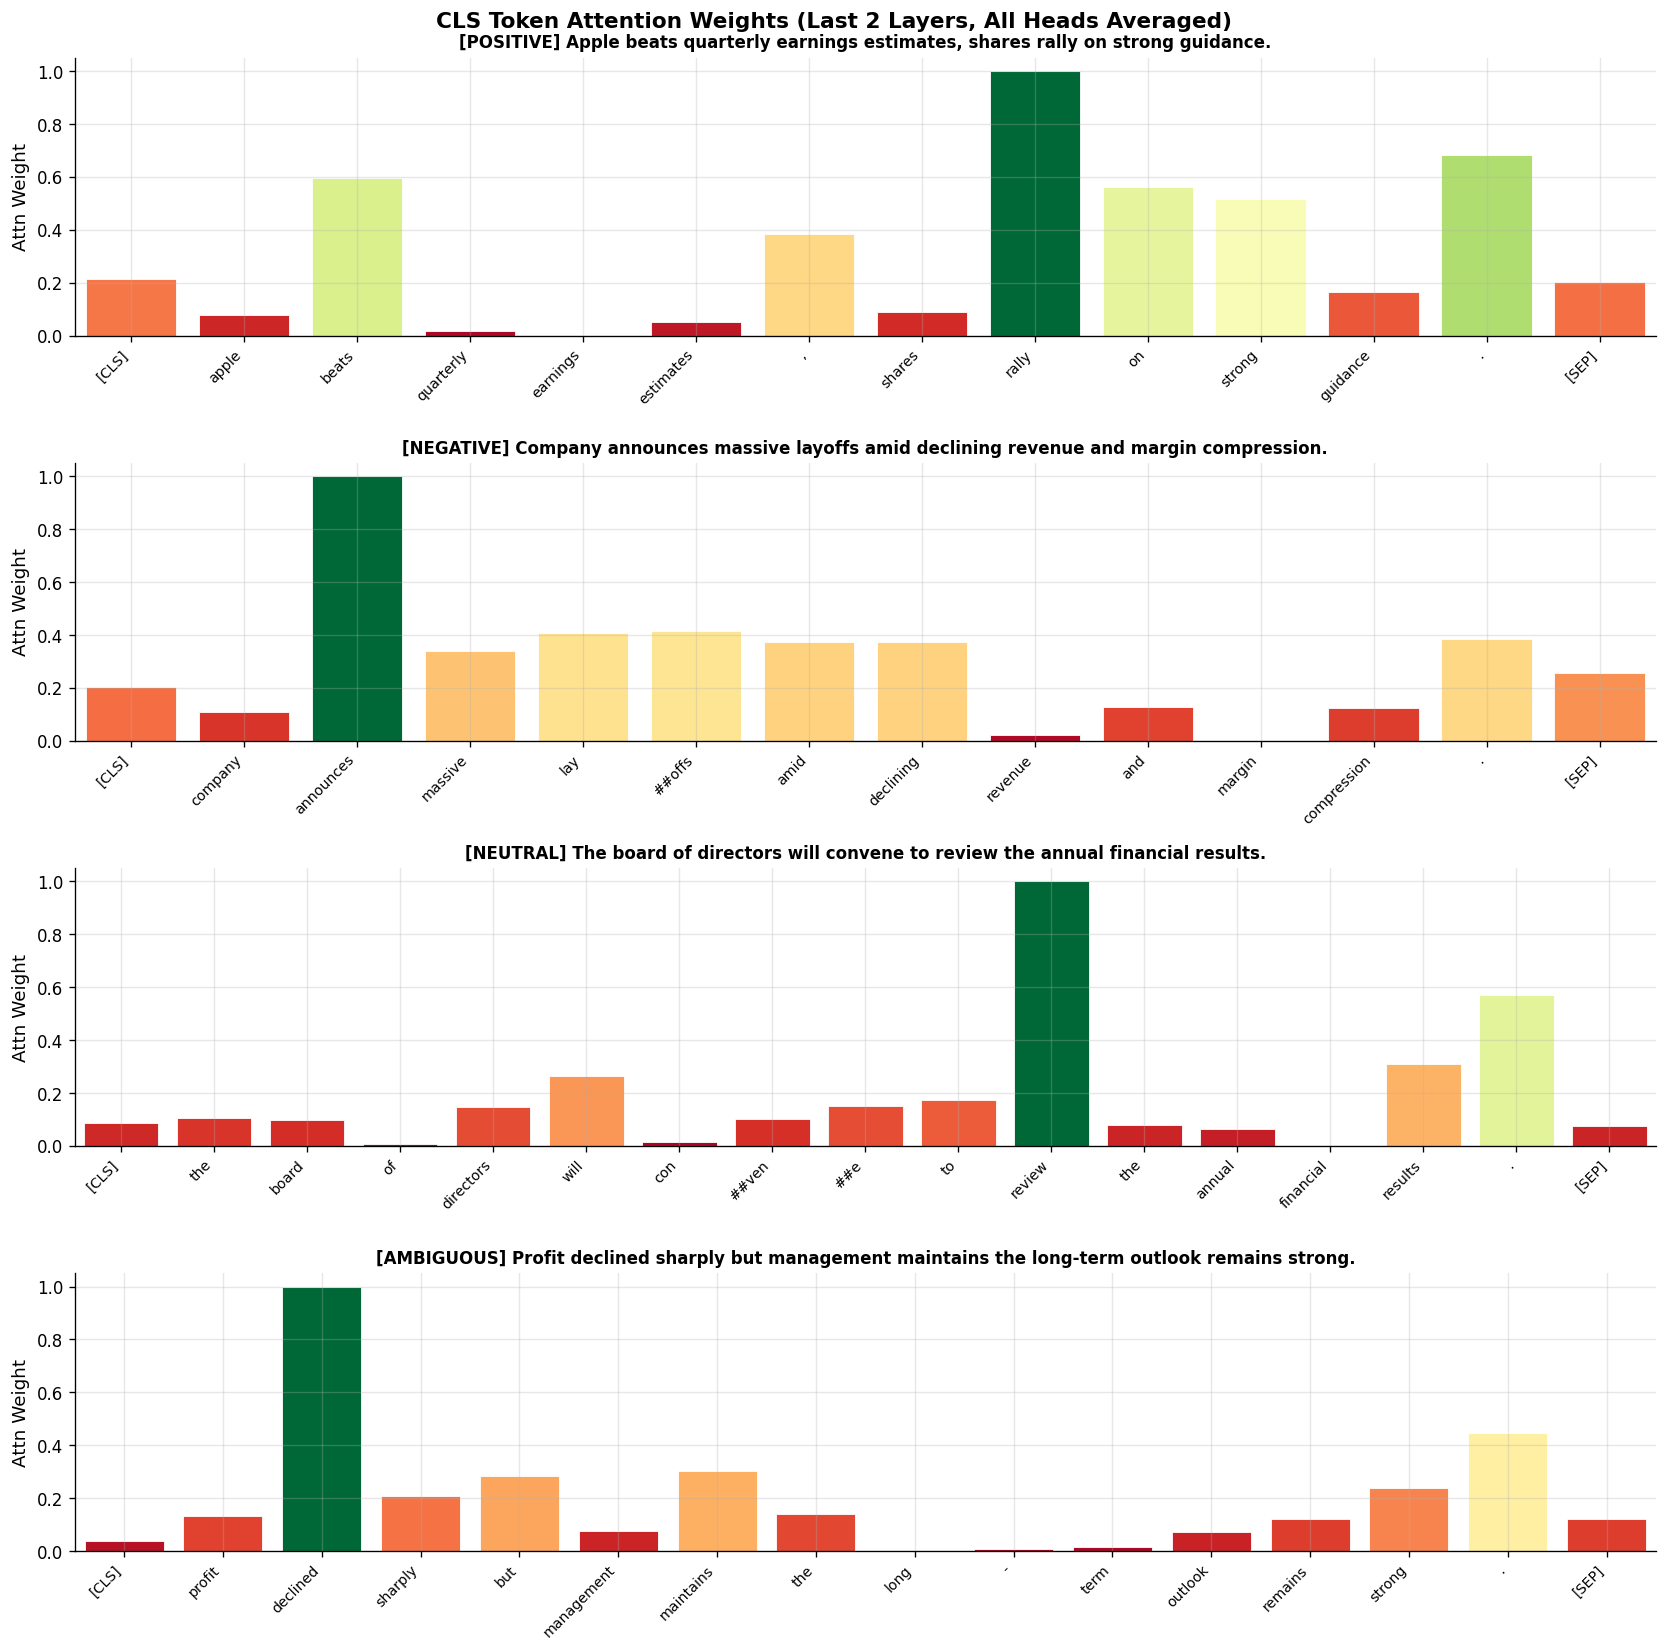

In [ ]:
ATTENTION_EXAMPLES = [
    ('positive', 'Apple beats quarterly earnings estimates, shares rally on strong guidance.'),
    ('negative', 'Company announces massive layoffs amid declining revenue and margin compression.'),
    ('neutral',  'The board of directors will convene to review the annual financial results.'),
    ('ambiguous', 'Profit declined sharply but management maintains the long-term outlook remains strong.'),
]

fig, axes = plt.subplots(len(ATTENTION_EXAMPLES), 1, figsize=(14, 3.5 * len(ATTENTION_EXAMPLES)))

for ax, (label, text) in zip(axes, ATTENTION_EXAMPLES):
    enc    = tokenizer(text, return_tensors='pt', max_length=128, truncation=True)
    ids    = enc['input_ids'].to(device)
    mask   = enc['attention_mask'].to(device)
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])

    with torch.no_grad():
        bert_out = model.encoder.bert(
            input_ids=ids, attention_mask=mask, output_attentions=True
        )
    #Average attention over all heads, last 2 layers, from [CLS] token
    attn_last2 = torch.stack(bert_out.attentions[-2:])  #[2, 1, heads, seq, seq]
    cls_attn   = attn_last2.mean(dim=(0, 1, 2))[0]      #mean over layers, batch, heads → [seq]
    cls_attn   = cls_attn[:len(tokens)].cpu().numpy()
    cls_attn   = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-9)

    colors = plt.cm.RdYlGn(cls_attn)  #red=low, green=high attention
    ax.bar(range(len(tokens)), cls_attn, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8.5)
    ax.set_ylabel('Attn Weight')
    ax.set_title(f'[{label.upper()}] {text}', fontweight='bold', fontsize=10)
    ax.set_xlim(-0.5, len(tokens) - 0.5)

plt.suptitle('CLS Token Attention Weights (Last 2 Layers, All Heads Averaged)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Detailed error analysis
error_idx = np.where(all_preds != all_labels)[0]
print(f'Total misclassifications: {len(error_idx)} / {len(all_labels)} ({len(error_idx)/len(all_labels):.1%})')
print()

#Confusion breakdown
print('ERROR PATTERNS:')
print(f'{"True→Predicted":<22} Count  Example')
print('-'*90)
for true_c in range(3):
    for pred_c in range(3):
        if true_c == pred_c: continue
        mask = (all_labels == true_c) & (all_preds == pred_c)
        idx  = np.where(mask)[0]
        if len(idx) == 0: continue
        example_text = X_te[idx[0]][:80]
        print(f'  {LABEL_NAMES[true_c]} → {LABEL_NAMES[pred_c]:<12}  {len(idx):>5}  "{example_text}"')

Total misclassifications: 101 / 484 (20.9%)

ERROR PATTERNS:
True→Predicted         Count  Example
------------------------------------------------------------------------------------------
  neutral → negative         25  "pentik+æinen emphasises that the most of the internet contents media houses prov"
  neutral → positive         66  "vacon aims to establish its presence in the solar energy business in various par"
  positive → negative          3  "in the fourth quarter of 2009 , atria 's net loss shrank to eur 1.2 million from"
  positive → neutral           7  "deliveries have started and the network will be ready for a launch soon ."


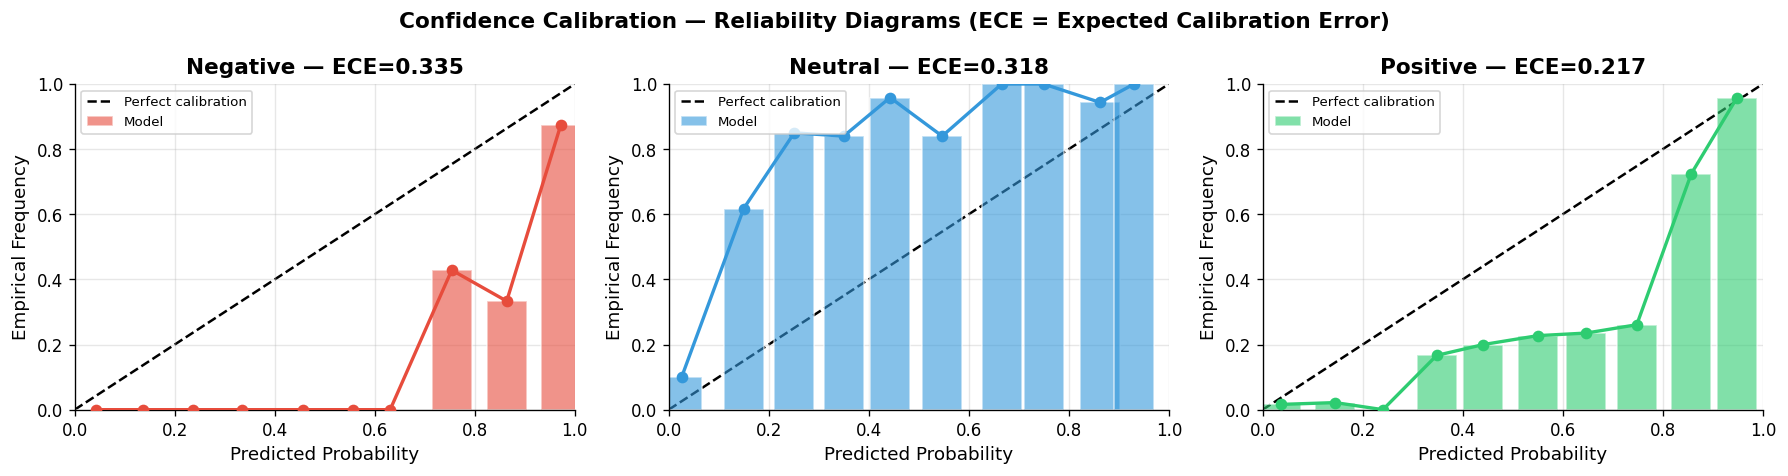

In [ ]:
#Reliability diagrams (calibration curves) per class
N_BINS = 10
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls_idx, cls_name in zip(axes, range(3), LABEL_NAMES):
    cls_probs  = all_probs[:, cls_idx]
    cls_binary = (all_labels == cls_idx).astype(int)

    bin_edges = np.linspace(0, 1, N_BINS + 1)
    bin_means, bin_acc = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (cls_probs >= lo) & (cls_probs < hi)
        if mask.sum() > 0:
            bin_means.append(cls_probs[mask].mean())
            bin_acc.append(cls_binary[mask].mean())

    ax.plot([0,1],[0,1], 'k--', linewidth=1.5, label='Perfect calibration', zorder=1)
    ax.bar(bin_means, bin_acc, width=0.08, alpha=0.6, color=FINANCIAL_COLORS[cls_name],
           label='Model', zorder=2, edgecolor='white')
    ax.plot(bin_means, bin_acc, 'o-', color=FINANCIAL_COLORS[cls_name], linewidth=2,
            markersize=6, zorder=3)

    #Expected Calibration Error
    ece = np.mean([abs(m - a) for m, a in zip(bin_means, bin_acc)])
    ax.set_title(f'{cls_name.capitalize()} — ECE={ece:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Empirical Frequency')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('Confidence Calibration — Reliability Diagrams (ECE = Expected Calibration Error)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Robustness study: adversarially ambiguous financial sentences
ADVERSARIAL = [
    ('Should be positive', 'Revenue declined but margins improved significantly this quarter.'),
    ('Should be positive', 'Profit fell sharply, yet the company raised its annual guidance.'),
    ('Should be negative', 'Strong headline numbers mask deteriorating free cash flow.'),
    ('Should be negative', 'Results beat estimates but management cut the dividend.'),
    ('Should be neutral',  'The company maintained its market position amid competitive headwinds.'),
    ('Should be neutral',  'CFO confirms no material change to fiscal year outlook at this time.'),
]

from utils.sentiment_inference import load_sentiment_model, predict_batch_sentiment
load_sentiment_model(str(Path(PROJECT_ROOT) / 'checkpoints' / 'finbert_sentiment_best.pt'))

texts_adv  = [t for _, t in ADVERSARIAL]
preds_adv  = predict_batch_sentiment(texts_adv)

print('ADVERSARIAL ROBUSTNESS STUDY')
print('='*90)
for (expected, text), pred in zip(ADVERSARIAL, preds_adv):
    correct = '✓' if expected.split()[2] in pred['label'] else '✗'
    print(f'{correct} [{expected:<22}] Predicted: {pred["label"]:8s} (conf={pred["score"]:.3f})')
    print(f'  Text: "{text}"')
    print(f'  Probs: neg={pred["probabilities"]["negative"]:.3f}  '
          f'neu={pred["probabilities"]["neutral"]:.3f}  '
          f'pos={pred["probabilities"]["positive"]:.3f}')
    print()

ADVERSARIAL ROBUSTNESS STUDY
✓ [Should be positive    ] Predicted: positive (conf=0.840)
  Text: "Revenue declined but margins improved significantly this quarter."
  Probs: neg=0.154  neu=0.006  pos=0.840

✗ [Should be positive    ] Predicted: negative (conf=0.810)
  Text: "Profit fell sharply, yet the company raised its annual guidance."
  Probs: neg=0.810  neu=0.011  pos=0.179

✓ [Should be negative    ] Predicted: negative (conf=0.958)
  Text: "Strong headline numbers mask deteriorating free cash flow."
  Probs: neg=0.958  neu=0.004  pos=0.038

✓ [Should be negative    ] Predicted: negative (conf=0.838)
  Text: "Results beat estimates but management cut the dividend."
  Probs: neg=0.838  neu=0.011  pos=0.151

✗ [Should be neutral     ] Predicted: positive (conf=0.644)
  Text: "The company maintained its market position amid competitive headwinds."
  Probs: neg=0.339  neu=0.016  pos=0.644

✓ [Should be neutral     ] Predicted: neutral  (conf=0.747)
  Text: "CFO confirms no material 

### Future Work

intelligence + scale + advanced AI

    - Multi-asset: crypto, forex, commodities, ETFs
    - Richer text: Reddit WSB, SEC 10-K/10-Q filings, Twitter
    - Longer horizons: 1-week, 1-month with temporal attention
    - PostgreSQL: persistent trade history + user portfolios
    - Redis: high-frequency sub-second caching layer
    - Dedicated model serving microservice
    - Reinforcement Learning: DQN/PPO agent learns optimal trading policies
    - Temporal Fusion Transformer or PatchTST replacing Bi-LSTM
    - Multi-agent consensus: sentiment + technical + macro signal ensemble
    - Financial LLM (FinLlama): document-level earnings call reasoning
    - Regime detection: separate models for bull / bear / volatile markets
